In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import os
import numpy as np

In [136]:
bluesky_df = pd.read_csv("Data\\1_Bronze\\Bluesky\\bsky_US_2024_raw.csv")

In [137]:
bluesky_df.head()

,uri,author,display,text,timestamp,likes,reposts,replies,mentions,is_reply,post_type,query,parent_uri
0,at://did:plc:taylv7omre5pg7arsuidtwg4/app.bsky.feed.post/3la5vzqu4lg2h,outrowes.bsky.social,Wes,"Os Swing States são os estados americanos onde a troca de casais é legalizada e amplamente praticada. No Brasil, os top 3 Swing States são: 1. São Paulo 2. Santa Catarina 3. Paraná #EleiçõesAmericanas #USElection2024 #USElections #USAElections #JN",2024-11-04T23:53:52.367Z,1,1,0,[],False,post,#USElection2024,NaN
1,at://did:plc:lpqouffbl3gbah3r23vh7odp/app.bsky.feed.post/3la5vify64y27,runhudi.bsky.social,Yehuda M.,"Canadian election prediction: Americans will go to the polls duped into the myth of democracy, believing that they are voting against the “enemy” MAGA/Libtards, while the real enemies, greed, corruption, injustice, & erosion of democracy, have gone unchecked for decades. 1/2 #USElection2024",2024-11-04T23:44:15.319Z,0,0,1,[],False,post,#USElection2024,NaN
2,at://did:plc:3ixumkojw3dpsfhdyjodfxmk/app.bsky.feed.post/3la5uykcup32n,manabouttown.bsky.social,NaN,Why are swinger states so important in the #USElection2024 ? Are there really *that* many sex people in the US?,2024-11-04T23:35:21.961Z,0,0,0,[],False,post,#USElection2024,NaN
3,at://did:plc:pebmhdoqw45rp5bpu53myfoc/app.bsky.feed.post/3la5udxpapl27,justdev1.bsky.social,That Dev Guy,"If Joe Biden winning felt like Return of the Jedi, then the end of this election will be like the ending to Rise of Skywalker. So god help us all. #StarWars #USElection2024",2024-11-04T23:23:51.647Z,0,0,0,[],False,post,#USElection2024,NaN
4,at://did:plc:bj6epztbrubmkloj4ethecvy/app.bsky.feed.post/3la5sfjyqk52u,alexverbeek.bsky.social,Alexander Verbeek,Will the U.S. Presidential Elections be a Turning Point in History? ➡️ theplanet.substack.com/p/will-the-u... #elections #USElection2024 #history,2024-11-04T22:48:56.805Z,3,1,1,[],False,post,#USElection2024,NaN


In [138]:
bluesky_df.columns

Index(['uri', 'author', 'display', 'text', 'timestamp', 'likes', 'reposts',
       'replies', 'mentions', 'is_reply', 'post_type', 'query', 'parent_uri'],
      dtype='object')

In [152]:
# Keep core columns
df = bluesky_df[['text', 'timestamp', 'likes', 'reposts', 'replies', 'mentions', 'is_reply', 'post_type']].copy()

df['timestamp'] = pd.to_datetime(df['timestamp'], errors='coerce', utc=True)

df = df.dropna(subset=['timestamp']).copy()

# Date/time features

ts = df['timestamp']
df['date'] = ts.dt.date
df['hour'] = ts.dt.hour
df['weekday'] = ts.dt.day_name()

print('rows', len(df), 'from', df['timestamp'].min(), 'to', df['timestamp'].max())
print('Distinct dates', df['date'].nunique())

rows 32159 from 2024-07-05 03:04:25.279000+00:00 to 2026-01-19 01:45:26.080000+00:00
Distinct dates 188


In [153]:
df.dtypes

text                      object
timestamp    datetime64[ns, UTC]
likes                      int64
reposts                    int64
replies                    int64
mentions                  object
is_reply                    bool
post_type                 object
date                      object
hour                       int32
weekday                   object
dtype: object

In [154]:
df['date'] = pd.to_datetime(df['date'])

In [155]:
df.head(1)

,text,timestamp,likes,reposts,replies,mentions,is_reply,post_type,date,hour,weekday
0,"Os Swing States são os estados americanos onde a troca de casais é legalizada e amplamente praticada. No Brasil, os top 3 Swing States são: 1. São Paulo 2. Santa Catarina 3. Paraná #EleiçõesAmericanas #USElection2024 #USElections #USAElections #JN",2024-11-04 23:53:52.367000+00:00,1,1,0,[],False,post,2024-11-04,23,Monday


In [156]:
df['text'].str.contains('#USElection2024').value_counts()

text
False    31794
True       365
Name: count, dtype: int64

In [157]:
df['text'] = df['text'].str.replace('#USElection2024', '', regex=True)
df['text'].str.contains('#USElection2024').value_counts()

text
False    32159
Name: count, dtype: int64

# 2.2 — Bluesky: Textual Analysis

<!-- toc -->
## Contents
      - [Analyzing Review Length Distribution](#analyzing-review-length-distribution)
      - [Word Count Distribution](#word-count-distribution)
    - [Basic Preprocessing steps](#basic-preprocessing-steps)
      - [Before vs. After Comparison](#before-vs-after-comparison)
      - [Creating the Document-Term Matrix with TF-IDF](#creating-the-document-term-matrix-with-tf-idf)
    - [SVD](#svd)
      - [Interpreting Latent Concepts](#interpreting-latent-concepts)
      - [Explained Variance](#explained-variance)
- [predictive setup --> create basetable for concatenation and feature engineering (train test split)](#predictive-setup----create-basetable-for-concatenation-and-feature-engineering-train-test-split)


#### Analyzing Review Length Distribution

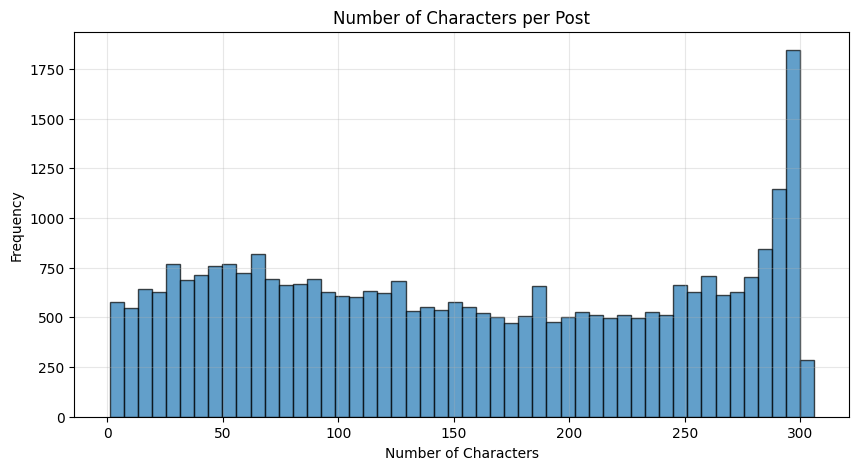

Average characters per post: 156.1
Median characters per post: 151.0


In [158]:
# Calculate character count for each review
char_counts = df['text'].str.len()

# Plot histogram
plt.figure(figsize=(10, 5))
plt.hist(char_counts, bins=50, edgecolor='black', alpha=0.7)
plt.xlabel('Number of Characters')
plt.ylabel('Frequency')
plt.title('Number of Characters per Post')
plt.grid(True, alpha=0.3)
plt.show()

print(f"Average characters per post: {char_counts.mean():.1f}")
print(f"Median characters per post: {char_counts.median():.1f}")

#### Word Count Distribution

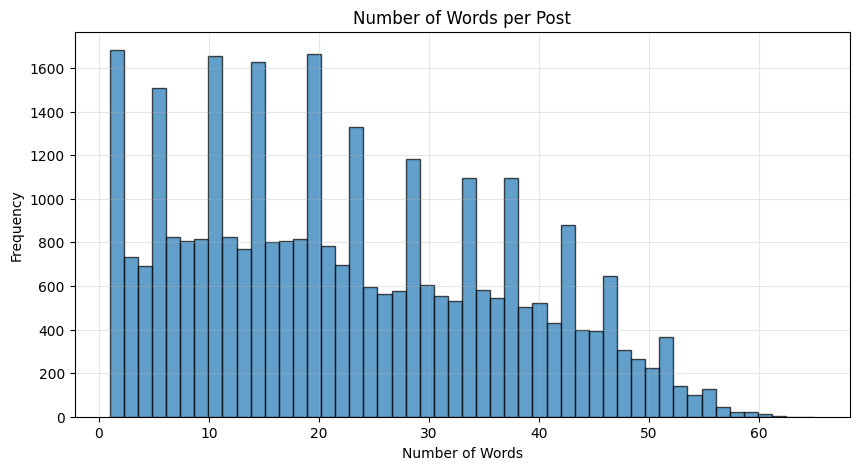

Average words per post: 22.6
Median words per post: 21.0


In [159]:
# Calculate word count for each review
word_counts = df['text'].str.split().str.len()

# Plot histogram
plt.figure(figsize=(10, 5))
plt.hist(word_counts, bins=50, edgecolor='black', alpha=0.7)
plt.xlabel('Number of Words')
plt.ylabel('Frequency')
plt.title('Number of Words per Post')
plt.grid(True, alpha=0.3)
plt.show()

print(f"Average words per post: {word_counts.mean():.1f}")
print(f"Median words per post: {word_counts.median():.1f}")

### Basic Preprocessing steps

In [160]:
import re

def unique_word_count(texts):
    """Count unique words across all documents."""
    if isinstance(texts, pd.Series):
        texts = texts.tolist()
    elif isinstance(texts, str):
        texts = [texts]
    
    unique_words = set()
    for text in texts:
        words = text.split()
        unique_words.update(words)
    
    return len(unique_words)

# Baseline: count unique words in original reviews before any preprocessing
baseline_count = unique_word_count(df['text'])
print(f"✓ Baseline unique words: {baseline_count:,}")
print(f"\nThis represents the vocabulary size before preprocessing.")

✓ Baseline unique words: 109,103

This represents the vocabulary size before preprocessing.


In [165]:
df['text'][3]

'If Joe Biden winning felt like Return of the Jedi, then the end of this election will be like the ending to Rise of Skywalker. So god help us all. #StarWars '

In [166]:
import re
from nltk.corpus import stopwords

# 1. Combine NLTK and your Custom Stopwords
stop_words_nltk = set(stopwords.words('english'))


# 2. Filtering the Date Range (July 5 to Nov 5)
# Ensure timestamp is datetime
df['timestamp'] = pd.to_datetime(df['timestamp'], errors='coerce')

# Filter for the specific range
mask = (df['timestamp'] >= '2024-07-05') & (df['timestamp'] <= '2024-11-05')
df = df.loc[mask].copy()

# 3. Updated Text cleaning pipeline
def clean_text(text):
    if pd.isna(text):
        return ''
    
    # Lowercase
    text = str(text).lower()
    
    # Remove URLs, Mentions, and Hashtags
    text = re.sub(r'https?://\S+|www\.\S+', '', text)
    text = re.sub(r'@[A-Za-z0-9_]+', '', text)
    text = re.sub(r'#([A-Za-z0-9_]+)', r'\1', text)  
      
    # Remove everything except letters (This fixes the underscore "_" issue)
    # This regex replaces underscores and punctuation with a space
    text = re.sub(r'[^a-z\s]', ' ', text)
    
    # Collapse multiple spaces into one
    text = re.sub(r'\s+', ' ', text).strip()
    
    # Remove combined Stopwords
    tokens = [w for w in text.split() if w not in stop_words_nltk]
    
    return ' '.join(tokens)

print('Applying text cleaning and filtering...')
df['text_clean'] = df['text'].apply(clean_text)

# Word metrics
df['words'] = df['text_clean'].str.split()
df['word_count'] = df['words'].str.len()

# Reset index to fix the "Doc 10.00" display issue in later steps
df = df.reset_index(drop=True)

print(f"Remaining rows after date filtering: {len(df)}")
print(df[['text_clean', 'word_count']].head(3))

Applying text cleaning and filtering...
Remaining rows after date filtering: 31909
                                                                                                                                                                                         text_clean  \
0  os swing states os estados americanos onde troca de casais legalizada e amplamente praticada brasil os top swing states paulo santa catarina paran elei esamericanas uselections usaelections jn   
1        canadian election prediction americans go polls duped myth democracy believing voting enemy maga libtards real enemies greed corruption injustice erosion democracy gone unchecked decades   
2                                                                                                                                                swinger states important really many sex people us   

   word_count  
0          28  
1          24  
2           8  


In [167]:
final_count = unique_word_count(df['text_clean'])

print(f"  Total reduction: {baseline_count - final_count:,} words")
print(f"  Final vocabulary: {final_count:,} unique words")
print(f"  Original vocabulary: {baseline_count:,} unique words")

  Total reduction: 62,599 words
  Final vocabulary: 46,504 unique words
  Original vocabulary: 109,103 unique words


#### Before vs. After Comparison

In [168]:
# Compare example review before and after preprocessing
idx = 20

print("="*80)
print("BEFORE PREPROCESSING:")
print("="*80)
print(df['text'].iloc[idx][:200])

print("="*80)
print("AFTER PREPROCESSING:")
print("="*80)
print(df['text_clean'].iloc[idx][:200])

BEFORE PREPROCESSING:
What happens if Trump loses  ? Forget the idea of a new civil war. Expect lots of chaos, violence and unrest. And a flood of #disinformation.
AFTER PREPROCESSING:
happens trump loses forget idea new civil war expect lots chaos violence unrest flood disinformation


no spell checking --> computationally expensive

no POS tagging

In [169]:
start_date = '2024-07-05'
end_date = '2024-11-05'

mask = (df['date'] >= start_date) & (df['date'] <= end_date)
df = df.loc[mask]

# 4. Optional: Reset the index so it starts from 0 again
df = df.reset_index(drop=True)

# 5. Check the result
print(f"Number of rows after filtering: {len(df)}")
print(f"Date range: {df['date'].min()} to {df['date'].max()}")

Number of rows after filtering: 31909
Date range: 2024-07-05 00:00:00 to 2024-11-04 00:00:00


In [172]:
df.head(1)

,text,timestamp,likes,reposts,replies,mentions,is_reply,post_type,date,hour,weekday,text_clean,words,word_count
0,"Os Swing States são os estados americanos onde a troca de casais é legalizada e amplamente praticada. No Brasil, os top 3 Swing States são: 1. São Paulo 2. Santa Catarina 3. Paraná #EleiçõesAmericanas #USElections #USAElections #JN",2024-11-04 23:53:52.367000+00:00,1,1,0,[],False,post,2024-11-04,23,Monday,os swing states os estados americanos onde troca de casais legalizada e amplamente praticada brasil os top swing states paulo santa catarina paran elei esamericanas uselections usaelections jn,"[os, swing, states, os, estados, americanos, onde, troca, de, casais, legalizada, e, amplamente, praticada, brasil, os, top, swing, states, paulo, santa, catarina, paran, elei, esamericanas, uselections, usaelections, jn]",28


#### Creating the Document-Term Matrix with TF-IDF

In [173]:
from sklearn.feature_extraction.text import TfidfVectorizer

# ── 1. Build TF-IDF vectorizer (following lecture parameters) ──
vectorizer = TfidfVectorizer(
    token_pattern=r'\b\w{2,}\b',  # Words with at least 2 characters (lecture default)
    lowercase=False,               # Already preprocessed
    max_features=None              # Keep all terms initially (lecture approach)
)

tfidf_matrix = vectorizer.fit_transform(df['text_clean'])
feature_names = vectorizer.get_feature_names_out()

print(f"DTM shape: {tfidf_matrix.shape}")
print(f"Documents : {tfidf_matrix.shape[0]}")
print(f"Terms     : {tfidf_matrix.shape[1]}")
sparsity = (1.0 - tfidf_matrix.nnz / (tfidf_matrix.shape[0] * tfidf_matrix.shape[1])) * 100
print(f"Sparsity  : {sparsity:.1f}%")

# ── 2. Inspect a sample (first 5 docs × first 10 terms) ──
dtm_df = pd.DataFrame(
    tfidf_matrix[:5, :10].toarray(),
    columns=feature_names[:10],
    index=[f'Doc {i+1}' for i in range(5)]
)
print("\nSample TF-IDF Matrix:")
print(dtm_df)

DTM shape: (31909, 46486)
Documents : 31909
Terms     : 46486
Sparsity  : 100.0%

Sample TF-IDF Matrix:
       aaa  aaaaaagh  aaaaaand  aaaaand  aaaah  aaand  aace  aai  aaid  \
Doc 1  0.0       0.0       0.0      0.0    0.0    0.0   0.0  0.0   0.0   
Doc 2  0.0       0.0       0.0      0.0    0.0    0.0   0.0  0.0   0.0   
Doc 3  0.0       0.0       0.0      0.0    0.0    0.0   0.0  0.0   0.0   
Doc 4  0.0       0.0       0.0      0.0    0.0    0.0   0.0  0.0   0.0   
Doc 5  0.0       0.0       0.0      0.0    0.0    0.0   0.0  0.0   0.0   

       aaliyah  
Doc 1      0.0  
Doc 2      0.0  
Doc 3      0.0  
Doc 4      0.0  
Doc 5      0.0  


In [179]:
# Find which documents contain 'aaaaaand'
term_idx = list(feature_names).index('aaaaaand')
doc_indices = tfidf_matrix[:, term_idx].nonzero()[0]

print(f"'aaaaaand' appears in {len(doc_indices)} documents:")
for idx in doc_indices:
    print(f"\nDoc {idx}: {df['text'].iloc[idx]}")

'aaaaaand' appears in 1 documents:

Doc 23896: Aaaaaand, here we go! The #VPDebate is live!


### SVD

In [180]:
from sklearn.decomposition import TruncatedSVD

# Start with maximum possible components
# For TruncatedSVD: n_components < min(n_samples, n_features)
n_docs = tfidf_matrix.shape[0]
n_terms = tfidf_matrix.shape[1]
max_components = min(n_docs, n_terms) - 1

print(f"Original matrix shape: {tfidf_matrix.shape}")
print(f"Maximum components: {max_components}")

# Apply TruncatedSVD with all possible components
svd_full = TruncatedSVD(n_components=min(100, max_components), random_state=42)
documents_concepts_full = svd_full.fit_transform(tfidf_matrix)

print(f"\nReduced matrix shape: {documents_concepts_full.shape}")
print(f"Dimensionality reduction: {n_terms} → {documents_concepts_full.shape[1]}")

Original matrix shape: (31909, 46486)
Maximum components: 31908

Reduced matrix shape: (31909, 100)
Dimensionality reduction: 46486 → 100


In [181]:
# 1. U matrix (document-by-concept): returned by transform()
print("1. Document-by-Concept Matrix (U):")
print(f"   Shape: {documents_concepts_full.shape}")
print(f"   This is what we use as features for machine learning!")
print(f"\n   First 5 documents, first 5 concepts:")
print(documents_concepts_full[:5, :5])

# 2. Sigma (Σ): singular values (strength of each concept)
print("\n2. Singular Values (Σ - diagonal of sigma matrix):")
print(f"   Shape: {svd_full.singular_values_.shape}")
print(f"   First 10 values: {svd_full.singular_values_[:10]}")

# 3. V^T matrix (concept-by-term): components_
print("\n3. Concept-by-Term Matrix (V^T):")
print(f"   Shape: {svd_full.components_.shape}")
print(f"   Shows how terms contribute to each concept")

1. Document-by-Concept Matrix (U):
   Shape: (31909, 100)
   This is what we use as features for machine learning!

   First 5 documents, first 5 concepts:
[[ 0.00754005  0.00654989  0.00651758  0.00441657  0.00107307]
 [ 0.03405112  0.07794907  0.01969934 -0.05764288  0.04551022]
 [ 0.02110843  0.03286681  0.02759441  0.01796543  0.01881357]
 [ 0.03448017  0.06783643  0.0204048  -0.00417176  0.04027031]
 [ 0.01787688  0.03825756  0.03016136  0.00617761  0.01416489]]

2. Singular Values (Σ - diagonal of sigma matrix):
   Shape: (100,)
   First 10 values: [20.61445248 19.31502409 16.21905731 13.03382862 12.79379228 12.05302304
 11.48935036 11.27351928 10.13482023 10.0411788 ]

3. Concept-by-Term Matrix (V^T):
   Shape: (100, 46486)
   Shows how terms contribute to each concept


#### Interpreting Latent Concepts

Each component represents a latent semantic concept. Let's examine which terms are most strongly associated with the first few concepts:

In [182]:
def display_top_terms_per_concept(svd_model, feature_names, n_top=10, n_concepts=5):
    """Display top terms for each latent concept."""
    for i in range(min(n_concepts, svd_model.n_components)):
        # Get component weights for all terms
        component = svd_model.components_[i]
        
        # Get indices of top terms (by absolute value)
        top_indices = np.argsort(np.abs(component))[::-1][:n_top]
        top_terms = [feature_names[idx] for idx in top_indices]
        top_weights = [component[idx] for idx in top_indices]
        
        print(f"\nConcept {i+1} (σ = {svd_full.singular_values_[i]:.3f}):")
        for term, weight in zip(top_terms, top_weights):
            print(f"  {term:20s} {weight:>8.4f}")

display_top_terms_per_concept(svd_full, feature_names, n_top=10, n_concepts=2)


Concept 1 (σ = 20.614):
  house                  0.3418
  co                     0.2330
  congress               0.2290
  sponsor                0.2235
  action                 0.2210
  gov                    0.2198
  latest                 0.2195
  sponsors               0.2194
  status                 0.2186
  introduced             0.2141

Concept 2 (σ = 19.315):
  trump                  0.3918
  election               0.2994
  vote                   0.2678
  kamalaharris           0.2200
  harris                 0.1971
  harriswalz             0.1828
  voteblue               0.1688
  maga                   0.1563
  house                 -0.1505
  votebluenomatterwho    0.1376


#### Explained Variance

The singular values tell us how much variance each component captures. We can use this to decide how many components to keep:

In [183]:
# Calculate variance explained by each component
# Variance is proportional to squared singular values
variance = svd_full.singular_values_ ** 2

# Calculate percentage of variance explained
total_variance = np.sum(variance)
explained_variance_ratio = variance / total_variance

# Cumulative variance
cumulative_variance = np.cumsum(explained_variance_ratio)

print("Variance Explained:")
print(f"{'Component':<12} {'Variance':<12} {'% Explained':<15} {'Cumulative %':<15}")
print("-" * 60)
for i in range(min(10, len(explained_variance_ratio))):
    print(f"{i+1:<12} {variance[i]:<12.4f} {explained_variance_ratio[i]*100:<15.2f} {cumulative_variance[i]*100:<15.2f}")

print(f"\nFirst 3 components explain {cumulative_variance[2]*100:.1f}% of variance")
print(f"First 5 components explain {cumulative_variance[4]*100:.1f}% of variance")

Variance Explained:
Component    Variance     % Explained     Cumulative %   
------------------------------------------------------------
1            424.9557     7.64            7.64           
2            373.0702     6.71            14.36          
3            263.0578     4.73            19.09          
4            169.8807     3.06            22.14          
5            163.6811     2.94            25.09          
6            145.2754     2.61            27.70          
7            132.0052     2.37            30.08          
8            127.0922     2.29            32.36          
9            102.7146     1.85            34.21          
10           100.8253     1.81            36.03          

First 3 components explain 19.1% of variance
First 5 components explain 25.1% of variance


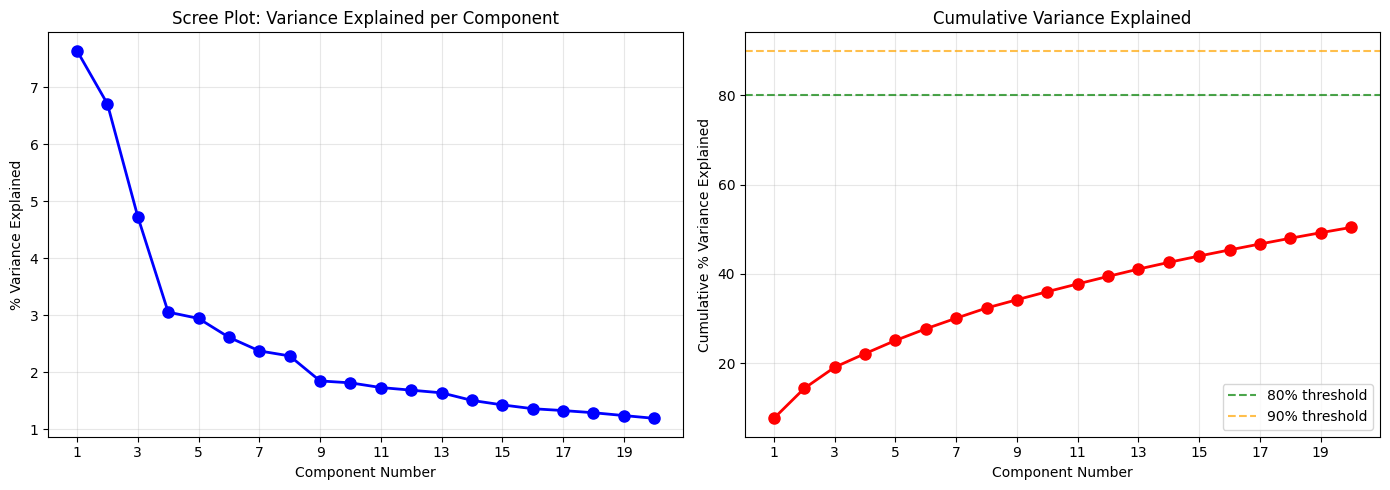

80% variance explained with 60 components
90% variance explained with 78 components
95% variance explained with 89 components


In [184]:
# Create scree plot
n_components_to_plot = min(20, len(explained_variance_ratio))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Variance explained per component
ax1.plot(range(1, n_components_to_plot + 1), 
         explained_variance_ratio[:n_components_to_plot] * 100, 
         'bo-', linewidth=2, markersize=8)
ax1.set_xlabel('Component Number')
ax1.set_ylabel('% Variance Explained')
ax1.set_title('Scree Plot: Variance Explained per Component')
ax1.grid(True, alpha=0.3)
ax1.set_xticks(range(1, n_components_to_plot + 1, 2))

# Plot 2: Cumulative variance explained
ax2.plot(range(1, n_components_to_plot + 1), 
         cumulative_variance[:n_components_to_plot] * 100, 
         'ro-', linewidth=2, markersize=8)
ax2.axhline(y=80, color='green', linestyle='--', label='80% threshold', alpha=0.7)
ax2.axhline(y=90, color='orange', linestyle='--', label='90% threshold', alpha=0.7)
ax2.set_xlabel('Component Number')
ax2.set_ylabel('Cumulative % Variance Explained')
ax2.set_title('Cumulative Variance Explained')
ax2.legend()
ax2.grid(True, alpha=0.3)
ax2.set_xticks(range(1, n_components_to_plot + 1, 2))

plt.tight_layout()
plt.show()

# Find number of components for common thresholds
for threshold in [0.80, 0.90, 0.95]:
    n_comp = np.argmax(cumulative_variance >= threshold) + 1
    print(f"{threshold*100:.0f}% variance explained with {n_comp} components")

In [185]:
# Create LSA model with optimal number of components
# Let's choose enough components to explain ~80% of variance
n_components_optimal = np.argmax(cumulative_variance >= 0.80) + 1

print(f"Using {n_components_optimal} components (explains {cumulative_variance[n_components_optimal-1]*100:.1f}% of variance)")

# Fit LSA model with reduced dimensionality
lsa = TruncatedSVD(n_components=n_components_optimal, random_state=42)
documents_lsa = lsa.fit_transform(tfidf_matrix)

print(f"\nOriginal dimensionality: {tfidf_matrix.shape[1]} terms")
print(f"Reduced dimensionality: {documents_lsa.shape[1]} concepts")
print(f"Dimensionality reduction: {(1 - documents_lsa.shape[1]/tfidf_matrix.shape[1])*100:.1f}%")

Using 60 components (explains 80.3% of variance)

Original dimensionality: 46486 terms
Reduced dimensionality: 60 concepts
Dimensionality reduction: 99.9%


In [190]:
documents_lsa.shape

(31909, 60)

In [200]:
df.shape

(31909, 14)

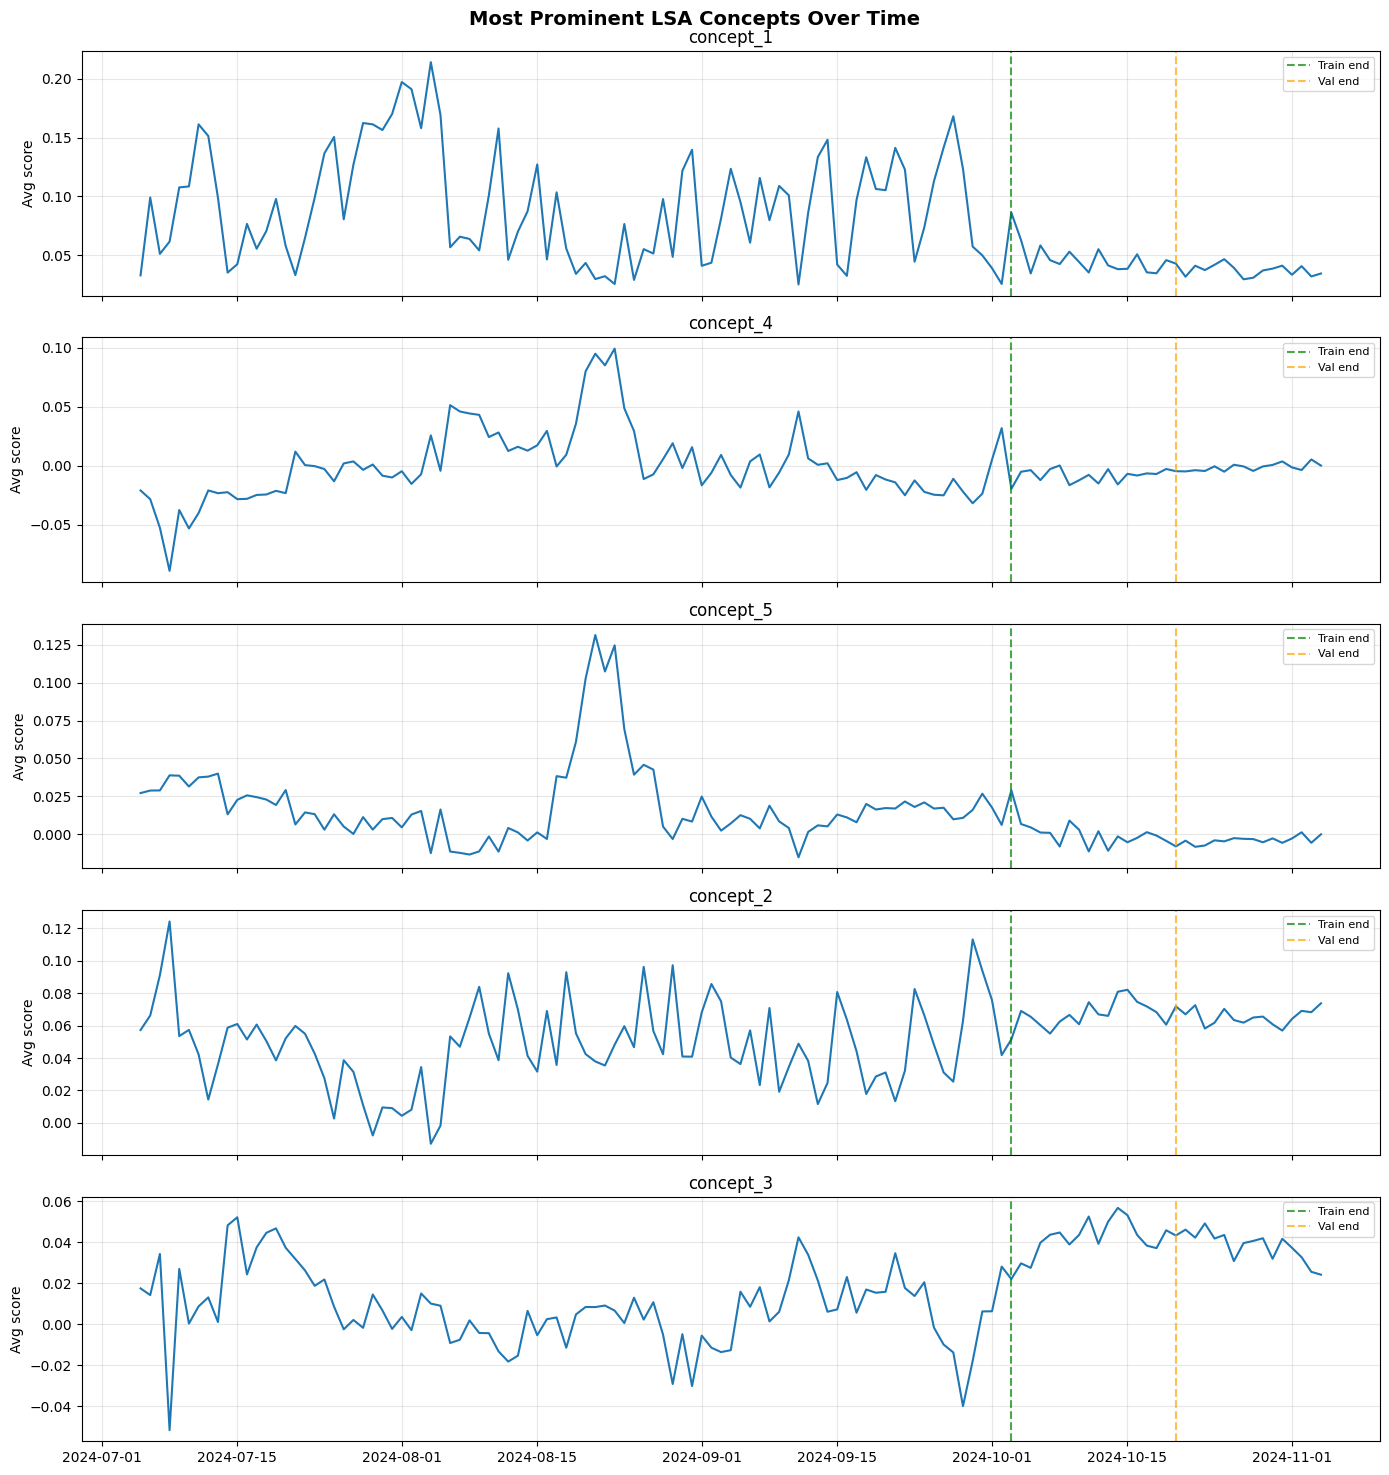

Top terms per concept:

concept_1: house, co, congress, sponsor, action, gov, latest, sponsors, status, introduced

concept_4: dnc, kamalaharris, harris, maga, kamala, wearenotgoingback, voteblue, timwalz, election, debate

concept_5: dnc, trump, kamalaharris, voteblue, wearenotgoingback, maga, election, politics, gop, yeswekam

concept_2: trump, election, vote, kamalaharris, harris, harriswalz, voteblue, maga, house, votebluenomatterwho

concept_3: trump, vote, maga, votebluenomatterwho, democracyontheballot, yourvotematters, democratsdeliver, harriswalz, kamalaharris, democrats


In [199]:
# ── Add date back to LSA matrix ───────────────────────────────────────────────
lsa_cols = [f'concept_{i+1}' for i in range(n_components_optimal)]

lsa_df = pd.DataFrame(documents_lsa, columns=lsa_cols, index=df.index)
lsa_df['date'] = df['date'].values

# ── Average concept scores per day ────────────────────────────────────────────
daily_concepts = lsa_df.groupby('date')[lsa_cols].mean()

# ── Plot top N most prominent concepts over time ──────────────────────────────
# Find top 5 concepts by overall variance (most "active" over time)
top_n = 5
top_concepts = daily_concepts.var().nlargest(top_n).index.tolist()

fig, axes = plt.subplots(top_n, 1, figsize=(14, 3 * top_n), sharex=True)

for ax, concept in zip(axes, top_concepts):
    ax.plot(daily_concepts.index, daily_concepts[concept], linewidth=1.5)
    ax.axvline(pd.Timestamp('2024-10-03'), color='green',  linestyle='--', alpha=0.7, label='Train end')
    ax.axvline(pd.Timestamp('2024-10-20'), color='orange', linestyle='--', alpha=0.7, label='Val end')
    ax.set_ylabel('Avg score')
    ax.set_title(concept)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8)

plt.suptitle('Most Prominent LSA Concepts Over Time', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# ── Print top terms per concept for interpretation ────────────────────────────
feature_names = vectorizer.get_feature_names_out()

print("Top terms per concept:")
for concept in top_concepts:
    idx = int(concept.split('_')[1]) - 1
    component = lsa.components_[idx]
    top_terms = [feature_names[i] for i in np.argsort(np.abs(component))[::-1][:10]]
    print(f"\n{concept}: {', '.join(top_terms)}")

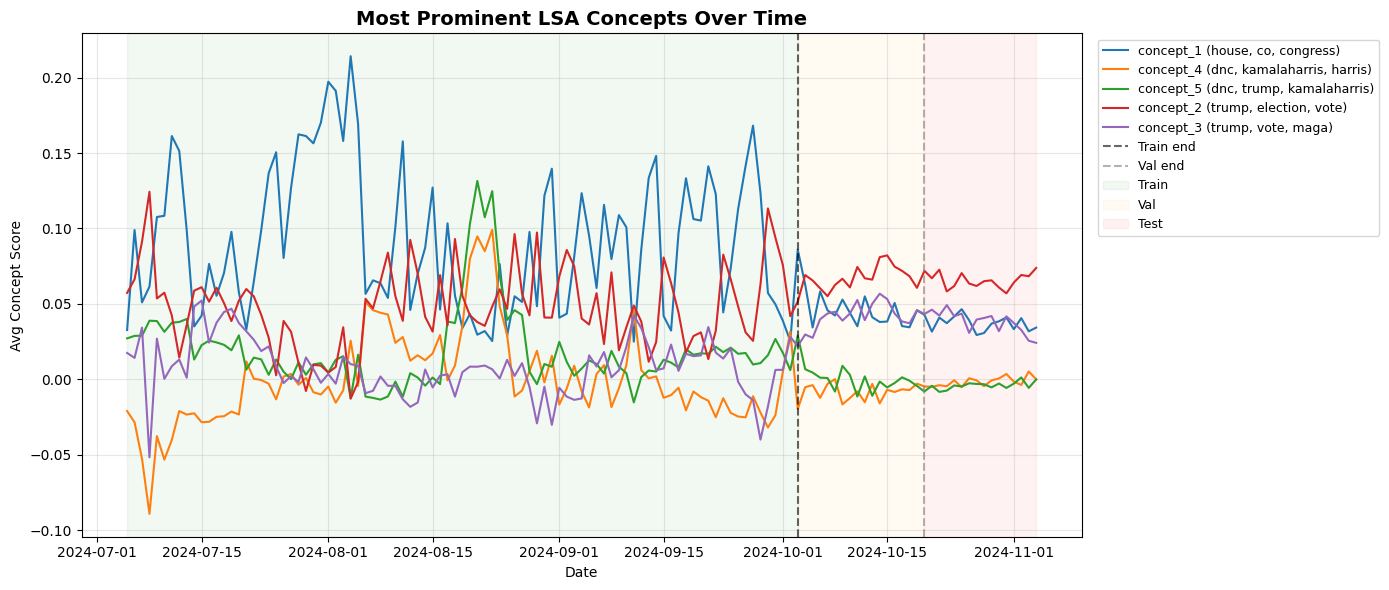

In [202]:
# ── Plot all top concepts on ONE graph ────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 6))

colors = plt.cm.tab10(range(top_n))

for concept, color in zip(top_concepts, colors):
    idx        = int(concept.split('_')[1]) - 1
    component  = lsa.components_[idx]
    top_terms  = [feature_names[i] for i in np.argsort(np.abs(component))[::-1][:5]]
    label      = f"{concept} ({', '.join(top_terms[:3])})"  # show top 3 terms in legend
    
    ax.plot(daily_concepts.index, daily_concepts[concept],
            linewidth=1.5, color=color, label=label)

# Train/val/test boundaries
ax.axvline(pd.Timestamp('2024-10-03'), color='black', linestyle='--', alpha=0.6, label='Train end')
ax.axvline(pd.Timestamp('2024-10-20'), color='gray',  linestyle='--', alpha=0.6, label='Val end')

# Shade regions
ax.axvspan(pd.Timestamp('2024-07-05'), pd.Timestamp('2024-10-03'), alpha=0.05, color='green',  label='Train')
ax.axvspan(pd.Timestamp('2024-10-03'), pd.Timestamp('2024-10-20'), alpha=0.05, color='orange', label='Val')
ax.axvspan(pd.Timestamp('2024-10-20'), pd.Timestamp('2024-11-04'), alpha=0.05, color='red',    label='Test')

ax.set_xlabel('Date')
ax.set_ylabel('Avg Concept Score')
ax.set_title('Most Prominent LSA Concepts Over Time', fontsize=14, fontweight='bold')
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

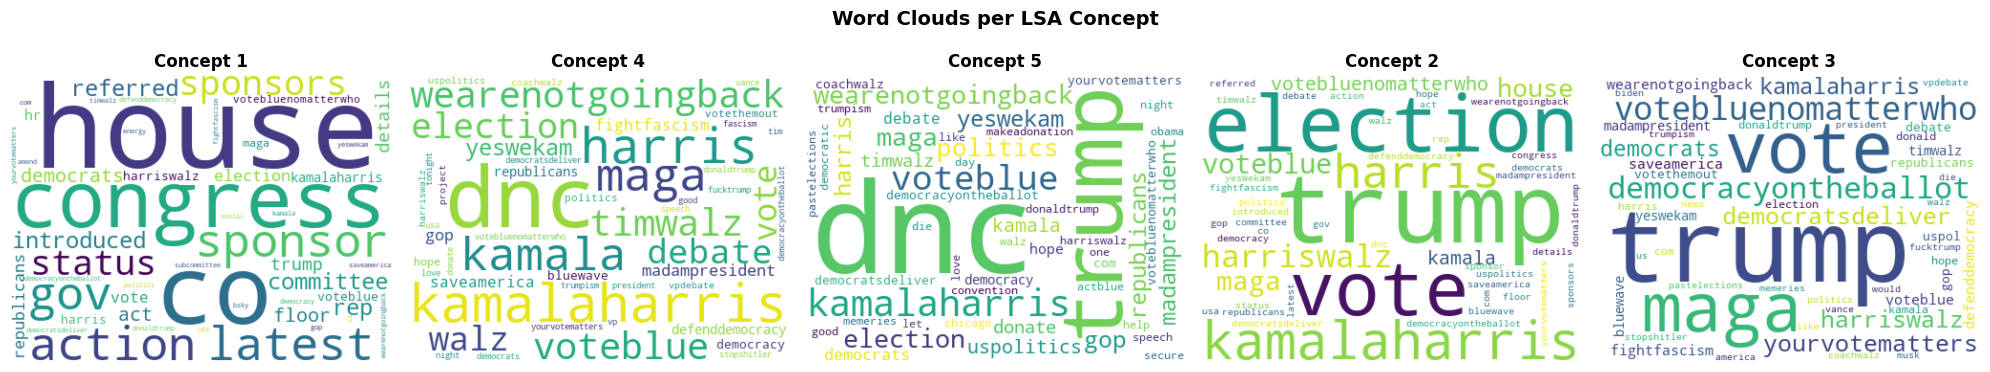

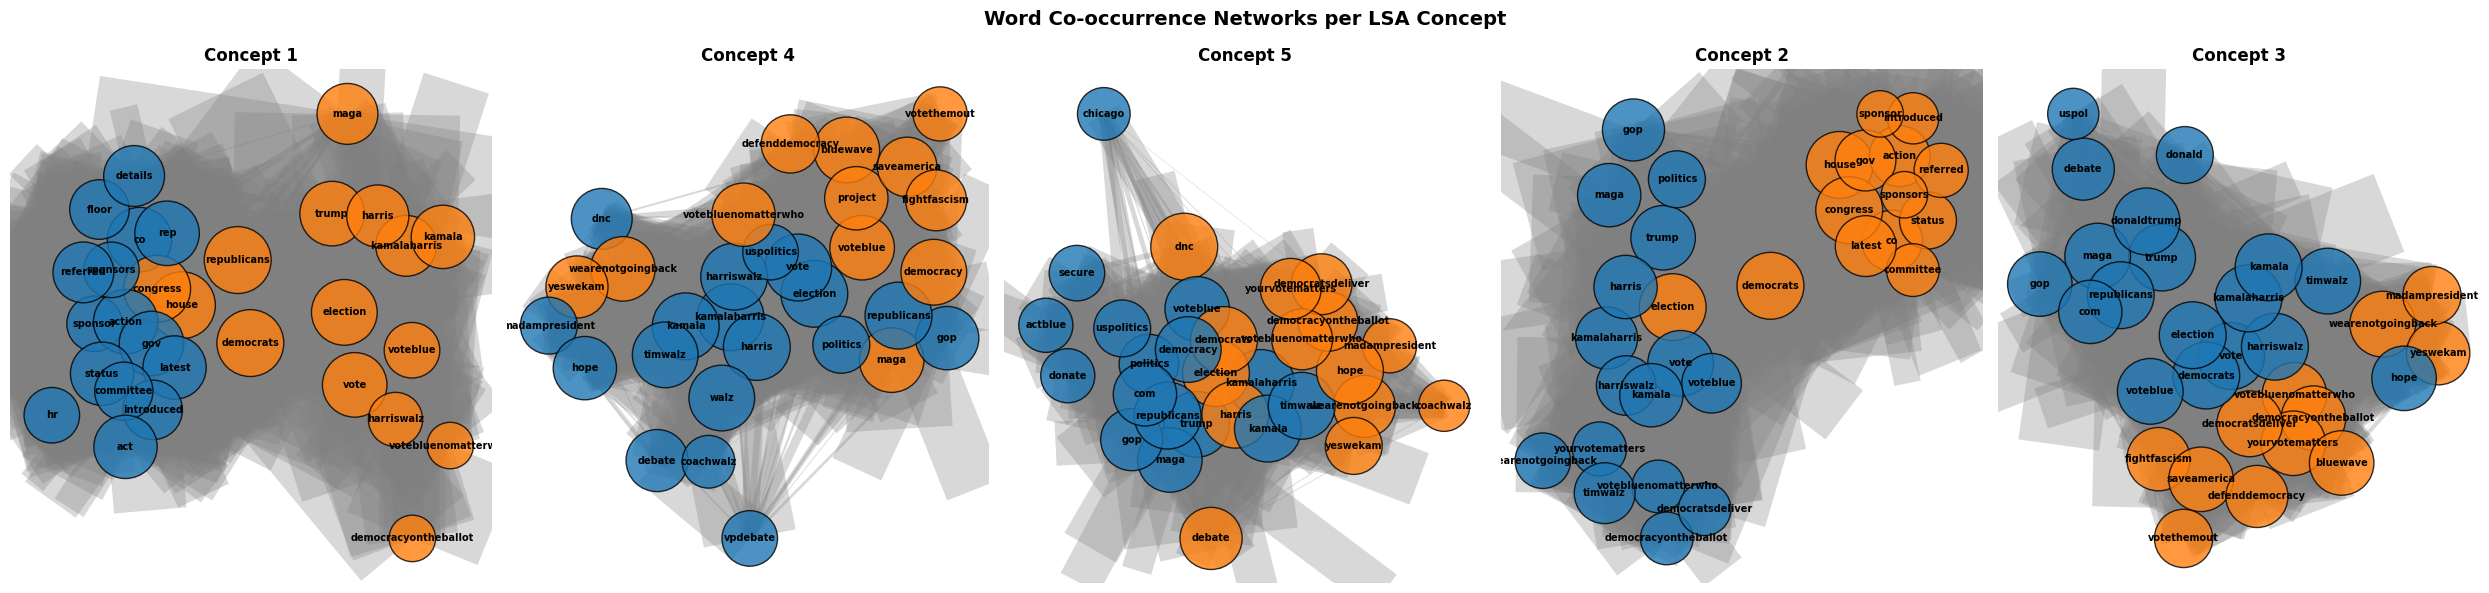

In [201]:
from wordcloud import WordCloud
from sklearn.feature_extraction.text import CountVectorizer
import networkx as nx
from networkx.algorithms import community
from collections import Counter

# ── Helper: get top terms + weights per concept ───────────────────────────────
def get_concept_terms(concept_idx, n_top=50):
    """Returns {term: abs_weight} dict for a concept — used for word cloud."""
    component = lsa.components_[concept_idx]
    top_idx   = np.argsort(np.abs(component))[::-1][:n_top]
    return {feature_names[i]: abs(component[i]) for i in top_idx}

# ── 1. WORD CLOUDS per concept (lecture style: weighted by LSA loadings) ───────
n_concepts_to_show = 5
top_concepts_idx = [int(c.split('_')[1]) - 1 for c in top_concepts]  # from earlier

fig, axes = plt.subplots(1, n_concepts_to_show, figsize=(20, 4))

for ax, concept_idx in zip(axes, top_concepts_idx):
    term_weights = get_concept_terms(concept_idx, n_top=50)
    
    wc = WordCloud(
        width=400, height=300,
        background_color='white',
        colormap='viridis',
        relative_scaling=0.5
    ).generate_from_frequencies(term_weights)
    
    ax.imshow(wc, interpolation='bilinear')
    ax.set_title(f'Concept {concept_idx+1}', fontweight='bold')
    ax.axis('off')

plt.suptitle('Word Clouds per LSA Concept', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# ── 2. WORD NETWORKS per concept (lecture style: co-occurrence network) ────────
def build_concept_network(concept_idx, n_top_terms=30, min_cooccur=2):
    """Build co-occurrence network for the top terms of a concept."""
    
    # Step 1: get top terms for this concept
    component  = lsa.components_[concept_idx]
    top_idx    = np.argsort(np.abs(component))[::-1][:n_top_terms]
    top_terms  = [feature_names[i] for i in top_idx]
    
    # Step 2: binary DTM restricted to these terms (lecture approach)
    binary_vec = CountVectorizer(
        vocabulary=top_terms,   # only the concept's top terms
        binary=True
    )
    dtm_binary = binary_vec.fit_transform(df['text_clean'])
    terms      = binary_vec.get_feature_names_out()
    
    # Step 3: co-occurrence matrix C = D^T × D (lecture formula)
    cooccur = (dtm_binary.T @ dtm_binary).toarray()
    np.fill_diagonal(cooccur, 0)  # remove self-loops
    
    # Step 4: build graph
    G = nx.Graph()
    for i, t_i in enumerate(terms):
        for j, t_j in enumerate(terms):
            if i < j and cooccur[i, j] >= min_cooccur:
                G.add_edge(t_i, t_j, weight=cooccur[i, j])
    
    return G, terms

fig, axes = plt.subplots(1, n_concepts_to_show, figsize=(25, 6))

for ax, concept_idx in zip(axes, top_concepts_idx):
    G, terms = build_concept_network(concept_idx, n_top_terms=30, min_cooccur=2)
    
    if G.number_of_nodes() == 0:
        ax.set_title(f'Concept {concept_idx+1}\n(no edges)')
        ax.axis('off')
        continue
    
    # Community detection (lecture style)
    communities   = community.greedy_modularity_communities(G)
    community_map = {node: i for i, comm in enumerate(communities) for node in comm}
    colors        = plt.cm.tab10(range(len(communities)))
    node_colors   = [colors[community_map[n]] for n in G.nodes()]
    
    # Layout + draw
    pos         = nx.spring_layout(G, k=1.5, seed=42)
    node_sizes  = [G.degree(n) * 80 for n in G.nodes()]
    edge_widths = [G[u][v]['weight'] / 5 for u, v in G.edges()]
    
    nx.draw_networkx_nodes(G, pos, ax=ax, node_size=node_sizes,
                           node_color=node_colors, alpha=0.8,
                           edgecolors='black', linewidths=1)
    nx.draw_networkx_edges(G, pos, ax=ax, width=edge_widths,
                           alpha=0.3, edge_color='gray')
    nx.draw_networkx_labels(G, pos, ax=ax, font_size=7, font_weight='bold')
    
    ax.set_title(f'Concept {concept_idx+1}', fontweight='bold')
    ax.axis('off')

plt.suptitle('Word Co-occurrence Networks per LSA Concept', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# predictive setup --> create basetable for concatenation and feature engineering (train test split)

In [192]:
df.dtypes

text                       object
timestamp     datetime64[ns, UTC]
likes                       int64
reposts                     int64
replies                     int64
mentions                   object
is_reply                     bool
post_type                  object
date               datetime64[ns]
hour                        int32
weekday                    object
text_clean                 object
words                      object
word_count                  int64
dtype: object

In [193]:
train_mask = (df['date'] >= '2024-07-05') & (df['date'] <= '2024-10-03')
val_mask   = (df['date'] >= '2024-10-04') & (df['date'] <= '2024-10-20')
test_mask  = (df['date'] >= '2024-10-21') & (df['date'] <= '2024-11-04')

train_df = df[train_mask].copy()
val_df   = df[val_mask].copy()
test_df  = df[test_mask].copy()

print(f"Train : {len(train_df)} posts ({train_df['date'].min()} → {train_df['date'].max()})")
print(f"Val   : {len(val_df)} posts ({val_df['date'].min()} → {val_df['date'].max()})")
print(f"Test  : {len(test_df)} posts ({test_df['date'].min()} → {test_df['date'].max()})")

Train : 14740 posts (2024-07-05 00:00:00 → 2024-10-03 00:00:00)
Val   : 5806 posts (2024-10-04 00:00:00 → 2024-10-20 00:00:00)
Test  : 11363 posts (2024-10-21 00:00:00 → 2024-11-04 00:00:00)


In [197]:
train_df.head(1)

,text,timestamp,likes,reposts,replies,mentions,is_reply,post_type,date,hour,weekday,text_clean,words,word_count
337,x.com/scottpwaldma...,2024-10-03 17:50:07.523000+00:00,0,0,0,[],False,post,2024-10-03,17,Thursday,x com scottpwaldma,"[x, com, scottpwaldma]",3


In [198]:
def aggregate_by_day(split_df):
    return split_df.groupby('date').agg(
        text_clean  = ('text_clean', lambda x: ' '.join(x)),        # concatenate
        words       = ('words',      lambda x: sum(x, [])),         # flatten lists
        likes       = ('likes',      'sum'),
        reposts     = ('reposts',    'sum'),
        replies     = ('replies',    'sum'),
        mentions    = ('mentions',   'sum'),
        word_count  = ('word_count', 'sum')
    ).reset_index()

daily_train = aggregate_by_day(train_df)
daily_val   = aggregate_by_day(val_df)
daily_test  = aggregate_by_day(test_df)

print(f"Train : {daily_train.shape} ({daily_train['date'].min()} → {daily_train['date'].max()})")
print(f"Val   : {daily_val.shape}   ({daily_val['date'].min()} → {daily_val['date'].max()})")
print(f"Test  : {daily_test.shape}  ({daily_test['date'].min()} → {daily_test['date'].max()})")

print("\nSample:")
print(daily_train.head(3))

Train : (91, 8) (2024-07-05 00:00:00 → 2024-10-03 00:00:00)
Val   : (17, 8)   (2024-10-04 00:00:00 → 2024-10-20 00:00:00)
Test  : (15, 8)  (2024-10-21 00:00:00 → 2024-11-04 00:00:00)

Sample:
        date  \
0 2024-07-05   
1 2024-07-06   
2 2024-07-07   

                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                       

In [203]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD

# ── 1. Fit TF-IDF on TRAIN only ───────────────────────────────────────────────
vectorizer = TfidfVectorizer(
    token_pattern=r'\b\w{2,}\b',
    lowercase=False,
    min_df=5,
    max_df=0.90
)

tfidf_train = vectorizer.fit_transform(daily_train['text_clean'])  # fit here only
tfidf_val   = vectorizer.transform(daily_val['text_clean'])        # transform only
tfidf_test  = vectorizer.transform(daily_test['text_clean'])       # transform only

feature_names = vectorizer.get_feature_names_out()

print(f"Vocabulary size : {len(feature_names)} terms")
print(f"TF-IDF train    : {tfidf_train.shape}")  # (n_train_days, n_terms)
print(f"TF-IDF val      : {tfidf_val.shape}")
print(f"TF-IDF test     : {tfidf_test.shape}")


Vocabulary size : 4466 terms
TF-IDF train    : (91, 4466)
TF-IDF val      : (17, 4466)
TF-IDF test     : (15, 4466)


In [205]:
# ── 2. Find optimal n_components on TRAIN ────────────────────────────────────
svd_full = TruncatedSVD(n_components=min(100, tfidf_train.shape[0]-1), random_state=42)
svd_full.fit_transform(tfidf_train)

variance             = svd_full.singular_values_ ** 2
explained_var_ratio  = variance / variance.sum()
cumulative_variance  = np.cumsum(explained_var_ratio)

n_components_optimal = np.argmax(cumulative_variance >= 0.80) + 1
print(f"\nOptimal components: {n_components_optimal} (explains {cumulative_variance[n_components_optimal-1]*100:.1f}% of train variance)")



Optimal components: 41 (explains 80.2% of train variance)


In [206]:
# ── 3. Fit LSA on TRAIN only, transform all splits ────────────────────────────
lsa = TruncatedSVD(n_components=n_components_optimal, random_state=42)

lsa_train = lsa.fit_transform(tfidf_train)  # fit here only
lsa_val   = lsa.transform(tfidf_val)        # transform only
lsa_test  = lsa.transform(tfidf_test)       # transform only

print(f"\nLSA train : {lsa_train.shape}")    # (n_train_days, n_components)
print(f"LSA val   : {lsa_val.shape}")
print(f"LSA test  : {lsa_test.shape}")




LSA train : (91, 41)
LSA val   : (17, 41)
LSA test  : (15, 41)


In [209]:
df.dtypes

text                       object
timestamp     datetime64[ns, UTC]
likes                       int64
reposts                     int64
replies                     int64
mentions                   object
is_reply                     bool
post_type                  object
date               datetime64[ns]
hour                        int32
weekday                    object
text_clean                 object
words                      object
word_count                  int64
dtype: object

In [210]:
lsa_cols = [f'concept_{i+1}' for i in range(n_components_optimal)]

# ── Keep engagement columns alongside LSA concepts ────────────────────────────
engagement_cols = ['date', 'likes', 'reposts', 'replies', 'word_count']

basetable_train = daily_train[engagement_cols].copy()
basetable_train[lsa_cols] = lsa_train

basetable_val = daily_val[engagement_cols].copy()
basetable_val[lsa_cols] = lsa_val

basetable_test = daily_test[engagement_cols].copy()
basetable_test[lsa_cols] = lsa_test

print(f"Basetable train : {basetable_train.shape}")
print(f"Basetable val   : {basetable_val.shape}")
print(f"Basetable test  : {basetable_test.shape}")
print("\nSample basetable (train):")
print(basetable_train.head(3))

Basetable train : (91, 46)
Basetable val   : (17, 46)
Basetable test  : (15, 46)

Sample basetable (train):
        date  likes  reposts  replies  word_count  concept_1  concept_2  \
0 2024-07-05     50       15       19         690   0.229810   0.169111   
1 2024-07-06     31       12        3         443   0.363516  -0.032058   
2 2024-07-07     52       14        7         393   0.203058   0.110811   

   concept_3  concept_4  concept_5  ...  concept_32  concept_33  concept_34  \
0   0.050561   0.284603   0.003042  ...   -0.105643    0.024169   -0.014300   
1   0.148847   0.232634  -0.099655  ...   -0.067278   -0.008697    0.054127   
2   0.020909   0.238577  -0.027474  ...    0.022080    0.009487   -0.054496   

   concept_35  concept_36  concept_37  concept_38  concept_39  concept_40  \
0   -0.044208   -0.023271   -0.054358   -0.004256   -0.104682    0.013160   
1   -0.163602    0.004564    0.096917   -0.038903   -0.045111    0.091481   
2    0.072005   -0.006958   -0.019403   -0.

In [212]:
# ── Define output path ────────────────────────────────────────────────────────
output_path = "Data/2_Silver/Bluesky/"
os.makedirs(output_path, exist_ok=True)

# ── Write to CSV ──────────────────────────────────────────────────────────────
basetable_train.to_csv(os.path.join(output_path, 'basetable_train.csv'), index=False)
basetable_val.to_csv(os.path.join(output_path,   'basetable_val.csv'),   index=False)
basetable_test.to_csv(os.path.join(output_path,  'basetable_test.csv'),  index=False)

print(f"✓ Written to {output_path}")
print(f"  basetable_train.csv : {basetable_train.shape}")
print(f"  basetable_val.csv   : {basetable_val.shape}")
print(f"  basetable_test.csv  : {basetable_test.shape}")

✓ Written to Data/2_Silver/Bluesky/
  basetable_train.csv : (91, 46)
  basetable_val.csv   : (17, 46)
  basetable_test.csv  : (15, 46)


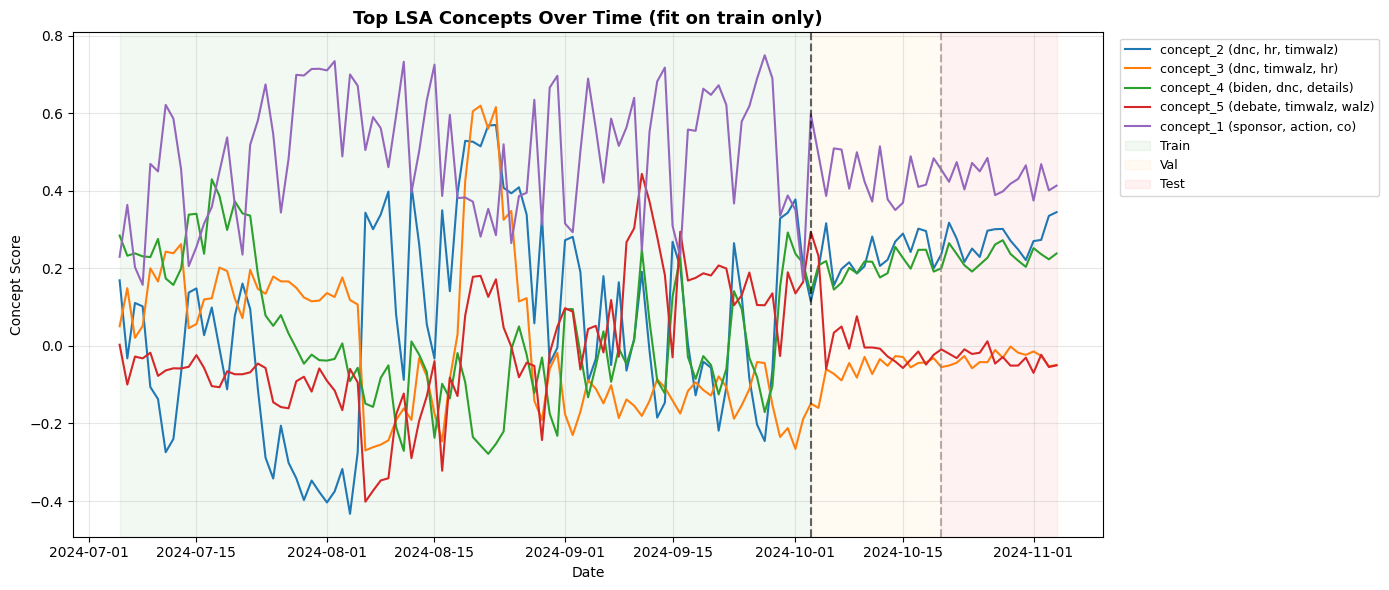

In [211]:
# ── 5. Visualise top concepts over time (all splits on one plot) ──────────────
# Find top 5 concepts by variance in TRAIN only
top_concepts = pd.DataFrame(lsa_train, columns=lsa_cols).var().nlargest(5).index.tolist()

# Combine all splits for plotting
all_concepts = pd.concat([basetable_train, basetable_val, basetable_test]).sort_values('date')

fig, ax = plt.subplots(figsize=(14, 6))
colors = plt.cm.tab10(range(len(top_concepts)))

for concept, color in zip(top_concepts, colors):
    idx       = int(concept.split('_')[1]) - 1
    top_terms = [feature_names[i] for i in np.argsort(np.abs(lsa.components_[idx]))[::-1][:3]]
    label     = f"{concept} ({', '.join(top_terms)})"
    ax.plot(all_concepts['date'], all_concepts[concept], linewidth=1.5, color=color, label=label)

ax.axvline(pd.Timestamp('2024-10-03'), color='black', linestyle='--', alpha=0.6)
ax.axvline(pd.Timestamp('2024-10-20'), color='gray',  linestyle='--', alpha=0.6)
ax.axvspan(pd.Timestamp('2024-07-05'), pd.Timestamp('2024-10-03'), alpha=0.05, color='green',  label='Train')
ax.axvspan(pd.Timestamp('2024-10-03'), pd.Timestamp('2024-10-20'), alpha=0.05, color='orange', label='Val')
ax.axvspan(pd.Timestamp('2024-10-20'), pd.Timestamp('2024-11-04'), alpha=0.05, color='red',    label='Test')

ax.set_xlabel('Date')
ax.set_ylabel('Concept Score')
ax.set_title('Top LSA Concepts Over Time (fit on train only)', fontsize=13, fontweight='bold')
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()